In [1]:
from einops import rearrange
import torch
from torch import nn
import numpy as np

# 验证 replay 里正奖励经验的存储情况
from collections import Counter


# 训练曲线: 原始 loss + 滑动平均, 便于观察趋势
import matplotlib.pyplot as plt
import numpy as np


### How to use rearrange

In [2]:

x = torch.randn(4, 7, 3, 5)
rearrange(x,"batch h w c -> batch c h w").shape


torch.Size([4, 5, 7, 3])

In [3]:

x = torch.rand(3, 49, 5)
rearrange(x,"batch (h w) c -> batch h w c", h=7).shape

torch.Size([3, 7, 7, 5])

### Multihead Module

In [4]:
class MultiHeadRelationalModule(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1_ch = 16
        self.conv2_ch = 20
        self.conv3_ch = 24
        self.conv4_ch = 30
        self.H = 28
        self.W = 28
        self.node_size = 64
        self.lin_hid = 100
        self.out_dim = 5
        self.ch_in = 3
        self.sp_coord_dim = 2
        self.N = int(7**2)
        self.n_heads = 3

        self.conv1 = nn.Conv2d(self.ch_in,self.conv1_ch,kernel_size=(1,1),padding=0)
        self.conv2 = nn.Conv2d(self.conv1_ch,self.conv2_ch,kernel_size=(1,1),padding=0)

        self.proj_shape = (self.conv2_ch+self.sp_coord_dim,self.n_heads * self.node_size)

        self.k_proj = nn.Linear(*self.proj_shape)
        self.q_proj = nn.Linear(*self.proj_shape)
        self.v_proj = nn.Linear(*self.proj_shape)

        self.k_lin = nn.Linear(self.node_size,self.N)
        self.q_lin = nn.Linear(self.node_size,self.N)
        self.a_lin = nn.Linear(self.N,self.N)

        self.node_shape = (self.n_heads,self.N,self.node_size)
        self.k_norm = nn.LayerNorm(self.node_shape,elementwise_affine=False)
        self.q_norm = nn.LayerNorm(self.node_shape,elementwise_affine=False)
        self.v_norm = nn.LayerNorm(self.node_shape,elementwise_affine=False)

        self.linear1 = nn.Linear(self.n_heads * self.node_size, self.node_size)
        self.norm1 = nn.LayerNorm([self.N,self.node_size],elementwise_affine=False)
        self.linear2 = nn.Linear(self.node_size, self.out_dim)

    def forward(self,x):
        B, Cin, H, W = x.shape

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

        # Saves a copy of the post-convolved input for later visualization
        with torch.no_grad():
            self.conv_map = x.clone()

        _, _, cH, cW = x.shape

        # 用 x.device 保证空间坐标与输入在同一设备上（GPU/CPU 都可用）
        xcoords = torch.arange(cW, device=x.device).repeat(cH,1).float() / cW
        ycoords = torch.arange(cH, device=x.device).repeat(cW,1).transpose(1,0).float() / cH

        spatial_coords = torch.stack([xcoords, ycoords],dim=0)
        spatial_coords = spatial_coords.unsqueeze(dim=0)
        spatial_coords = spatial_coords.repeat(B, 1, 1, 1)

        x = torch.cat([x,spatial_coords],dim=1)

        x = x.permute(0,2,3,1)
        x = x.flatten(1,2)

        K = rearrange(self.k_proj(x), "b n (head d) -> b head n d",head=self.n_heads)
        K = self.k_norm(K)

        Q = rearrange(self.q_proj(x), "b n (head d) -> b head n d",head=self.n_heads)
        Q = self.q_norm(Q)

        V = rearrange(self.v_proj(x), "b n (head d) -> b head n d",head=self.n_heads)
        V = self.v_norm(V)

        # A = Q @ K.T
        # A = torch.einsum('bhfe,bhge->bhfg',Q,K)
        # A = A / np.sqrt(self.node_size)
        # A = torch.nn.functional.softmax(A,dim=3)
        A = torch.nn.functional.elu(self.k_lin(K)+self.q_lin(Q))
        A = self.a_lin(A)
        A = torch.nn.functional.softmax(A, dim=3) # d

        # Saves a copy of the attention weights for later visualization
        with torch.no_grad():
            self.att_map = A.clone()

        E = torch.einsum('bhfc,bhcd->bhfd',A,V)
        E = rearrange(E, 'B head n d -> B n (head d)')
        E = self.linear1(E)
        E = torch.relu(E)
        E = self.norm1(E)
        E = E.max(dim=1)[0]
        # E = E.mean(dim=1)   # (B, 49, 64) -> (B, 64) !not work


        # Q-value 输出保持与书本一致 (带 ELU); 若发现坍缩再实验去掉
        y = self.linear2(E)
        y = torch.nn.functional.elu(y)
        
        return y


In [5]:
import gymnasium as gym
from minigrid.wrappers import ImgObsWrapper

# 全局设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_state(x:np.array):
    # MiniGrid ImgObsWrapper 返回 (W, H, C), permute 成 (C, H, W)
    # 注意 permute 参数是 (2,0,1) 而不是 (1,2,0):
    #   原始 dims (W=0, H=1, C=2)
    #   目标 dims (C, H, W) -> 用 (2, 1, 0) 会转置 H/W, 用 (2, 0, 1) 保持自然顺序
    ns = torch.from_numpy(x).float().permute(2,0,1).unsqueeze(dim=0)
    return ns.to(device)


def get_minibatch(replay,size):
    batch_ids = np.random.randint(0, len(replay), size)
    batch = [replay[id] for id in batch_ids]

    state_batch = torch.cat([exp[0] for exp in batch]).to(device)
    action_batch = torch.tensor([exp[1] for exp in batch], dtype=torch.long, device=device)
    reward_batch = torch.tensor([exp[2] for exp in batch], dtype=torch.float32, device=device)
    state2_batch = torch.cat([exp[3] for exp in batch]).to(device)
    done_batch = torch.tensor([exp[4] for exp in batch], dtype=torch.float32, device=device)
    return state_batch,action_batch,reward_batch,state2_batch, done_batch


def get_qtarget_ddqn(qvals,r,df,done):
    # Calculates the target Q value
    # df: gamma
    targets = r + (1-done) * df * qvals
    return targets


In [6]:
# Def loss function

def lossfn(pred, targets, actions):
    loss = torch.mean(torch.pow(targets.detach()-pred.gather(dim=1,index=actions.unsqueeze(dim=1)),2))
    return loss

def update_replay(replay,exp,replay_size):
    r = exp[2] # get the reward of this exp
    N = 1
    if r > 0: # if result is positive , multiply to prioritize
        N = 100
    for i in range(N):
        replay.append(exp)
    return replay

# Maps the action outputs of 
# the DQN to a subset of actions in the environment
action_map = {
    0:0,
    1:1,
    2:2,
    3:3,
    4:5 # <- here
}

### Training

In [7]:
losses = []

epochs_length = []

In [ ]:
import time
from collections import deque

# 训练循环里加逐步诊断 (只在前 N 步 或每隔 K 步打印, 避免刷屏)
DEBUG_UNTIL = 20        # 前 20 步每步打印
DEBUG_EVERY = 500       # 之后每 500 步打印一次


# gym.make() 负责创建环境，ImgObsWrapper 负责修改环境的 observation 形式，
# 让它直接返回图像数据，方便 CNN/DQN 使用。
env = ImgObsWrapper(gym.make('MiniGrid-DoorKey-5x5-v0'))
print(env)
plt.imshow(env)
state = prepare_state(env.reset()[0])



<ImgObsWrapper<OrderEnforcing<PassiveEnvChecker<DoorKeyEnv<MiniGrid-DoorKey-5x5-v0>>>>>


In [9]:

def _shrink_init(m, scale=0.1):
    for p in m.parameters():
        with torch.no_grad():
            p.mul_(scale)

GWagent = MultiHeadRelationalModule().to(device)
_shrink_init(GWagent, scale=0.1)

_shrink_init(GWagent, scale=0.1)


Tnet = MultiHeadRelationalModule().to(device)
Tnet.load_state_dict(GWagent.state_dict())

# 把两个网络放到 GPU（若可用）
GWagent = MultiHeadRelationalModule().to(device)
Tnet = MultiHeadRelationalModule().to(device)
Tnet.load_state_dict(GWagent.state_dict())


<All keys matched successfully>

In [10]:

maxsteps = 400
env.unwrapped.max_steps = maxsteps

epochs = 30000
replay_size = 9000
lr = 0.0005
gamma = 0.99
batch_size = 64  # 必须 < replay_size, 否则训练分支永远不会触发

replay = deque(maxlen=replay_size)

opt = torch.optim.Adam(params=GWagent.parameters(),lr=lr)

eps = 0.6
update_freq = 100

t0 = time.time()

eps_len = 0
for i in range(epochs):
    done = False
    eps_len += 1
    
    with torch.no_grad():
        pred = GWagent(state) # 5 action value
    action = int(torch.argmax(pred))
    # ε-greedy: 用均匀分布 rand()，而非 randn()
    if np.random.rand() < eps:
        action = int(torch.randint(0,5,size=(1,)).squeeze())
    action_d = action_map[action]

    state2, reward, terminated, truncated, info = env.step(action_d)

    state2 = prepare_state(state2)
    reward = -0.01 if reward == 0 else reward
    if terminated or truncated: done = True
    exp = (state, action, reward, state2, done ) # action or action_d?

    replay = update_replay(replay,exp,replay_size)

        # === 诊断 ===
    if i < DEBUG_UNTIL or i % DEBUG_EVERY == 0:
        q_np = pred.squeeze().cpu().numpy()
        q_spread = q_np.max() - q_np.min()
        s_mean = state.mean().item()
        s_std = state.std().item()
        print(f"i={i:5d} | Q={q_np.round(3)} spread={q_spread:.4f} "
              f"| a={action} r={reward:+.2f} term={terminated} trunc={truncated} "
              f"| s: mean={s_mean:.3f} std={s_std:.3f}")

        
    if done:
        state = prepare_state(env.reset()[0])
        env.unwrapped.max_steps = maxsteps
        epochs_length.append(eps_len)
        eps_len = 0
    else:
        state = state2

    if len(replay) > batch_size:

        opt.zero_grad()

        state_batch, action_batch, reward_batch, state2_batch, done_batch = \
            get_minibatch(replay, batch_size)

        q_pred = GWagent(state_batch)
        astar = torch.argmax(q_pred,dim=1)
        qs = Tnet(state2_batch).gather(dim=1,index=astar.unsqueeze(dim=1)).squeeze()

        targets = get_qtarget_ddqn(qs.detach(),reward_batch,gamma,done_batch)

        loss = lossfn(q_pred,targets.detach(),action_batch)

        losses.append(loss.detach().cpu().item())

        # === 诊断 gradient/训练 ===
        if i < DEBUG_UNTIL or i % DEBUG_EVERY == 0:
            print(f"       train | loss={loss.item():.4f} "
                  f"| target: mean={targets.mean().item():.3f} std={targets.std().item():.3f} "
                  f"| q_pred: mean={q_pred.mean().item():.3f} std={q_pred.std().item():.3f} "
                  f"| reward batch mean={reward_batch.mean().item():+.3f}")

            
        loss.backward()

        # 打印梯度范数, 看是否消失
        if i < DEBUG_UNTIL or i % DEBUG_EVERY == 0:
            total_grad = sum(p.grad.norm().item()**2 for p in GWagent.parameters() if p.grad is not None) ** 0.5
            l2_grad = GWagent.linear2.weight.grad.norm().item()
            print(f"       grad  | total={total_grad:.4f} linear2={l2_grad:.4f}")

            
        # Clips the gradients to prevent overly large gradients
        torch.nn.utils.clip_grad_norm_(GWagent.parameters(), max_norm=1.0)
        opt.step()

        if i % update_freq == 0:
            Tnet.load_state_dict(GWagent.state_dict())

    if (i+1) % 2000 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i+1) * (epochs - i - 1)
        recent = losses[-100:] if losses else []
        avg = sum(recent)/len(recent) if recent else float('nan')
        print(f"epoch {i+1}/{epochs} | elapsed {elapsed/60:.1f}min | ETA {eta/60:.1f}min | loss(avg100) {avg:.4f}")

print(f"done in {(time.time()-t0)/60:.1f} min")


i=    0 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=2 r=-0.01 term=False trunc=False | s: mean=0.408 std=1.232
i=    1 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=4 r=-0.01 term=False trunc=False | s: mean=0.408 std=1.232
i=    2 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=2 r=-0.01 term=False trunc=False | s: mean=0.408 std=1.232
i=    3 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=4 r=-0.01 term=False trunc=False | s: mean=0.408 std=1.232
i=    4 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=2 r=-0.01 term=False trunc=False | s: mean=0.408 std=1.232
i=    5 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=2 r=-0.01 term=False trunc=False | s: mean=0.408 std=1.232
i=    6 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=2 r=-0.01 term=False trunc=False | s: mean=0.408 std=1.232
i=    7 | Q=[-0.234 -0.433 -0.143 -0.412 -0.38 ] spread=0.2898 | a=2 r=-0.01 term=False trunc=False | s: mean=0.408 st

In [11]:
for name, p in GWagent.named_parameters():
    if p.grad is not None:
        print(name, p.grad.norm().item())

conv1.weight 1.7960853710974334e-06
conv1.bias 1.1027847222067066e-06
conv2.weight 4.950128641212359e-06
conv2.bias 4.6592849685112014e-06
k_proj.weight 2.593255885585677e-07
k_proj.bias 7.305743565666489e-08
q_proj.weight 2.4529924758098787e-07
q_proj.bias 6.27649470175129e-08
v_proj.weight 2.3573649741592817e-05
v_proj.bias 2.6426454496686347e-05
k_lin.weight 2.964490875001502e-07
k_lin.bias 2.880818783523864e-08
q_lin.weight 2.575921769221168e-07
q_lin.bias 2.880818783523864e-08
a_lin.weight 2.3552522634417983e-06
a_lin.bias 2.7434003868620493e-07
linear1.weight 0.0002370042202528566
linear1.bias 1.6889698599698022e-05
linear2.weight 0.03031233698129654
linear2.bias 0.00378848216496408


In [12]:


# 1. 直接统计正/负奖励条目数
pos_count = sum(1 for e in replay if e[2] > 0)
neg_count = sum(1 for e in replay if e[2] <= 0)
print(f'total in replay: {len(replay)}')
print(f'positive-reward entries: {pos_count}')
print(f'non-positive entries:    {neg_count}')

# 2. 正奖励经验应该以 50 的倍数出现 (每次 update_replay 追加 50 份)
# 用 (state_id, action, reward) 做粗糙的 dedup key. 因为 state 是 tensor, 用 data_ptr 或 flatten
def exp_key(e):
    s, a, r, s2, d = e
    return (s.data_ptr(), a, round(r, 4))

pos_experiences = [e for e in replay if e[2] > 0]
pos_multiplicity = Counter(exp_key(e) for e in pos_experiences)
print(f'\ndistinct positive experiences in replay: {len(pos_multiplicity)}')
print(f'each appears (multiplicity):')
for key, count in pos_multiplicity.most_common(10):
    print(f'  {key} -> {count} copies')

# 3. 是否有正奖励经验的 multiplicity 不是 50?
unexpected = {k: v for k, v in pos_multiplicity.items() if v not in (50,)}
if unexpected:
    print(f'\nWARNING: {len(unexpected)} positive experiences have multiplicity != 50 '
          f'(可能是 deque 满了之后被后续 experience 挤掉了一部分)')
    for k, v in list(unexpected.items())[:5]:
        print(f'  {k} -> {v} copies (expected 50)')
else:
    print('\n✓ every positive experience has exactly 50 copies')

# 4. 抽样检查: 手动 append 一个正奖励看是否真的 +50
test_replay = deque(maxlen=100)
dummy_state = torch.zeros(1, 3, 5, 5)
pos_exp = (dummy_state, 0, 1.0, dummy_state, True)
neg_exp = (dummy_state, 0, -0.01, dummy_state, False)

test_replay = update_replay(test_replay, neg_exp, 100)
test_replay = update_replay(test_replay, pos_exp, 100)
print(f'\n=== manual test ===')
print(f'after 1 neg + 1 pos: len={len(test_replay)} (expected 51: 1 neg + 50 pos)')
print(f'  neg count: {sum(1 for e in test_replay if e[2] <= 0)}, '
      f'pos count: {sum(1 for e in test_replay if e[2] > 0)}')


total in replay: 9000
positive-reward entries: 700
non-positive entries:    8300

distinct positive experiences in replay: 7
each appears (multiplicity):
  (137146641431040, 2, 0.4667) -> 100 copies
  (137146638192128, 2, 0.1607) -> 100 copies
  (137146638669824, 2, 0.1743) -> 100 copies
  (137146643317248, 2, 0.8267) -> 100 copies
  (137146850056192, 2, 0.415) -> 100 copies
  (137146846598656, 2, 0.5297) -> 100 copies
  (137146638261760, 2, 0.5613) -> 100 copies

  (137146641431040, 2, 0.4667) -> 100 copies (expected 50)
  (137146638192128, 2, 0.1607) -> 100 copies (expected 50)
  (137146638669824, 2, 0.1743) -> 100 copies (expected 50)
  (137146643317248, 2, 0.8267) -> 100 copies (expected 50)
  (137146850056192, 2, 0.415) -> 100 copies (expected 50)

=== manual test ===
after 1 neg + 1 pos: len=100 (expected 51: 1 neg + 50 pos)
  neg count: 0, pos count: 100


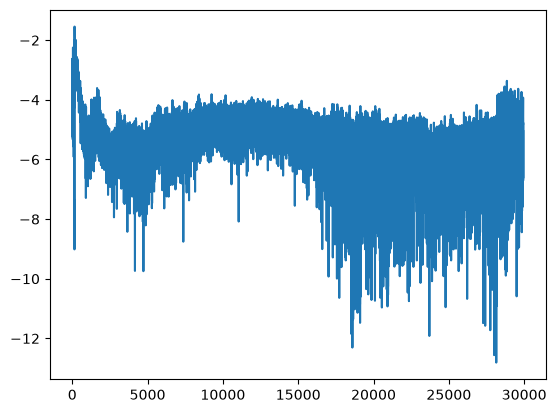

In [13]:
import matplotlib.pyplot as plt

plt.plot(np.log(losses))

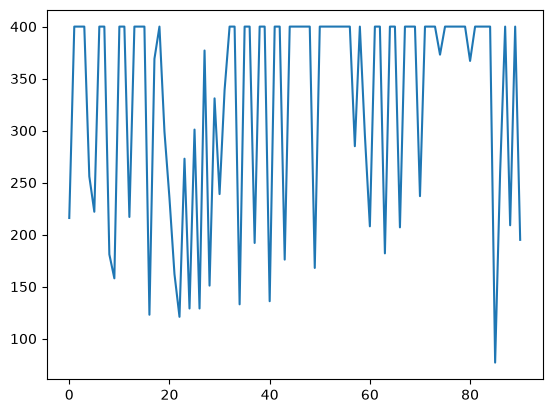

In [14]:
plt.plot(epochs_length)

In [15]:
min(epochs_length)

77

In [16]:
# 测试: 关闭探索, 用贪心策略跑若干 episode, 统计成功率与平均步数
GWagent.eval()

n_eval = 50
successes = 0
step_counts = []
returns = []

with torch.no_grad():
    for ep in range(n_eval):
        s = prepare_state(env.reset()[0])
        ep_return, steps, done = 0.0, 0, False
        while not done:
            q = GWagent(s)
            a = int(torch.argmax(q))
            s2, r, terminated, truncated, _ = env.step(action_map[a])
            ep_return += r
            steps += 1
            done = terminated or truncated
            s = prepare_state(s2)
        if terminated and ep_return > 0:  # MiniGrid: 到达目标 reward > 0
            successes += 1
        step_counts.append(steps)
        returns.append(ep_return)

print(f"success rate: {successes}/{n_eval} = {successes/n_eval:.1%}")
print(f"avg steps:   {np.mean(step_counts):.1f}")
print(f"avg return:  {np.mean(returns):.3f}")
GWagent.train()


success rate: 0/50 = 0.0%
avg steps:   400.0
avg return:  0.000


MultiHeadRelationalModule(
  (conv1): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(16, 20, kernel_size=(1, 1), stride=(1, 1))
  (k_proj): Linear(in_features=22, out_features=192, bias=True)
  (q_proj): Linear(in_features=22, out_features=192, bias=True)
  (v_proj): Linear(in_features=22, out_features=192, bias=True)
  (k_lin): Linear(in_features=64, out_features=49, bias=True)
  (q_lin): Linear(in_features=64, out_features=49, bias=True)
  (a_lin): Linear(in_features=49, out_features=49, bias=True)
  (k_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (q_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (v_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (linear1): Linear(in_features=192, out_features=64, bias=True)
  (norm1): LayerNorm((49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (linear2): Linear(in_features=64, out_features=5, bias=True)
)

In [17]:
# 可视化: 用 rgb_array 渲染一次 episode, 用 matplotlib 动画播放
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import torch.nn.functional as F

tau = 1.0  # 温度: 越小越接近 argmax, 越大越接近均匀
probs = F.softmax(q.squeeze() / tau, dim=-1)

# 用 render_mode='rgb_array' 创建一个新 env, 不影响训练用的 env
env_vis = ImgObsWrapper(gym.make('MiniGrid-DoorKey-5x5-v0', render_mode='rgb_array'))
env_vis.unwrapped.max_steps = 100

GWagent.eval()
frames = []
actions_taken = []
qvals_hist = []

with torch.no_grad():
    obs, _ = env_vis.reset()
    s = prepare_state(obs)
    frames.append(env_vis.render())
    done = False
    while not done:
        q = GWagent(s)
        # a = int(torch.argmax(q))
        a = int(torch.multinomial(probs, num_samples=1))
        actions_taken.append(a)
        qvals_hist.append(q.squeeze().cpu().numpy().round(3))
        obs, r, term, trunc, _ = env_vis.step(action_map[a])
        frames.append(env_vis.render())
        done = term or trunc
        s = prepare_state(obs)

GWagent.train()
print(f"episode length: {len(frames)-1} steps, terminated: {term}, reward: {r}")
print(f"unique actions taken: {sorted(set(actions_taken))}")
print(f"first 5 Q-values:  {qvals_hist[:5]}")

# 生成动画
fig, ax = plt.subplots(figsize=(4,4))
ax.axis('off')
im = ax.imshow(frames[0])

action_names = {0:'left', 1:'right', 2:'forward', 3:'pickup', 5:'toggle'}
def update(i):
    im.set_data(frames[i])
    if i < len(actions_taken):
        a = actions_taken[i]
        ax.set_title(f"step {i}: action={action_names.get(action_map[a],a)}")
    else:
        ax.set_title(f"step {i}: END")
    return [im]

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=300, blit=False)
plt.close()
HTML(anim.to_jshtml())


episode length: 100 steps, terminated: False, reward: 0
unique actions taken: [0, 1, 2, 3, 4]
first 5 Q-values:  [array([0.258, 0.255, 0.259, 0.257, 0.257], dtype=float32), array([0.258, 0.255, 0.259, 0.257, 0.257], dtype=float32), array([0.258, 0.255, 0.259, 0.257, 0.257], dtype=float32), array([0.258, 0.255, 0.259, 0.257, 0.257], dtype=float32), array([0.258, 0.255, 0.259, 0.257, 0.257], dtype=float32)]


In [18]:
# 诊断: 网络是否对不同输入产生不同输出?
# 如果所有 state 都得到相同 Q, 说明网络坍缩; 需要架构或训练策略层面修改
GWagent.eval()

# 从 replay 里抽 5 个不同 state, 检查 Q 输出
import random
if len(replay) >= 5:
    samples = random.sample(list(replay), 5)
    print("=== Q-values across 5 different states from replay ===")
    with torch.no_grad():
        for i, exp in enumerate(samples):
            s = exp[0]
            q = GWagent(s).squeeze().cpu().numpy()
            # 检查 state 本身是否不同
            s_signature = s.flatten()[:5].cpu().numpy().round(3)
            print(f"state {i}: input[:5]={s_signature}, Q={q.round(4)}")

# 手动构造两个明显不同的 state (全 0 vs 全 1) 看输出差异
print("\n=== Q-values for synthetic inputs ===")
with torch.no_grad():
    z = torch.zeros(1, 3, 7, 7, device=device)
    o = torch.ones(1, 3, 7, 7, device=device)
    r = torch.rand(1, 3, 7, 7, device=device)
    print(f"all zeros: Q={GWagent(z).squeeze().cpu().numpy().round(4)}")
    print(f"all ones:  Q={GWagent(o).squeeze().cpu().numpy().round(4)}")
    print(f"random:    Q={GWagent(r).squeeze().cpu().numpy().round(4)}")

# 检查最后一层参数是否已训练 (是否非零, 是否有梯度)
print("\n=== linear2 weight stats ===")
w = GWagent.linear2.weight.detach().cpu().numpy()
b = GWagent.linear2.bias.detach().cpu().numpy()
print(f"weight mean={w.mean():.4f}, std={w.std():.4f}, min={w.min():.4f}, max={w.max():.4f}")
print(f"bias: {b.round(4)}")

GWagent.train()


=== Q-values across 5 different states from replay ===
state 0: input[:5]=[0. 0. 0. 2. 2.], Q=[0.258  0.2548 0.2588 0.2567 0.2571]
state 1: input[:5]=[0. 0. 0. 0. 0.], Q=[0.2577 0.2546 0.2589 0.2571 0.257 ]
state 2: input[:5]=[0. 0. 0. 0. 0.], Q=[0.2579 0.2547 0.2588 0.2567 0.2571]
state 3: input[:5]=[0. 0. 0. 0. 0.], Q=[0.2579 0.2547 0.2588 0.2568 0.2571]
state 4: input[:5]=[0. 0. 0. 0. 0.], Q=[0.2579 0.2547 0.2588 0.2568 0.257 ]

=== Q-values for synthetic inputs ===
all zeros: Q=[0.2578 0.2547 0.2588 0.257  0.257 ]
all ones:  Q=[0.2576 0.2549 0.2587 0.2567 0.2573]
random:    Q=[0.2577 0.255  0.2587 0.2567 0.2573]

=== linear2 weight stats ===
weight mean=-0.0016, std=0.0658, min=-0.1589, max=0.1319
bias: [ 0.0797 -0.0668  0.0938 -0.0547  0.0695]


MultiHeadRelationalModule(
  (conv1): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(16, 20, kernel_size=(1, 1), stride=(1, 1))
  (k_proj): Linear(in_features=22, out_features=192, bias=True)
  (q_proj): Linear(in_features=22, out_features=192, bias=True)
  (v_proj): Linear(in_features=22, out_features=192, bias=True)
  (k_lin): Linear(in_features=64, out_features=49, bias=True)
  (q_lin): Linear(in_features=64, out_features=49, bias=True)
  (a_lin): Linear(in_features=49, out_features=49, bias=True)
  (k_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (q_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (v_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (linear1): Linear(in_features=192, out_features=64, bias=True)
  (norm1): LayerNorm((49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (linear2): Linear(in_features=64, out_features=5, bias=True)
)

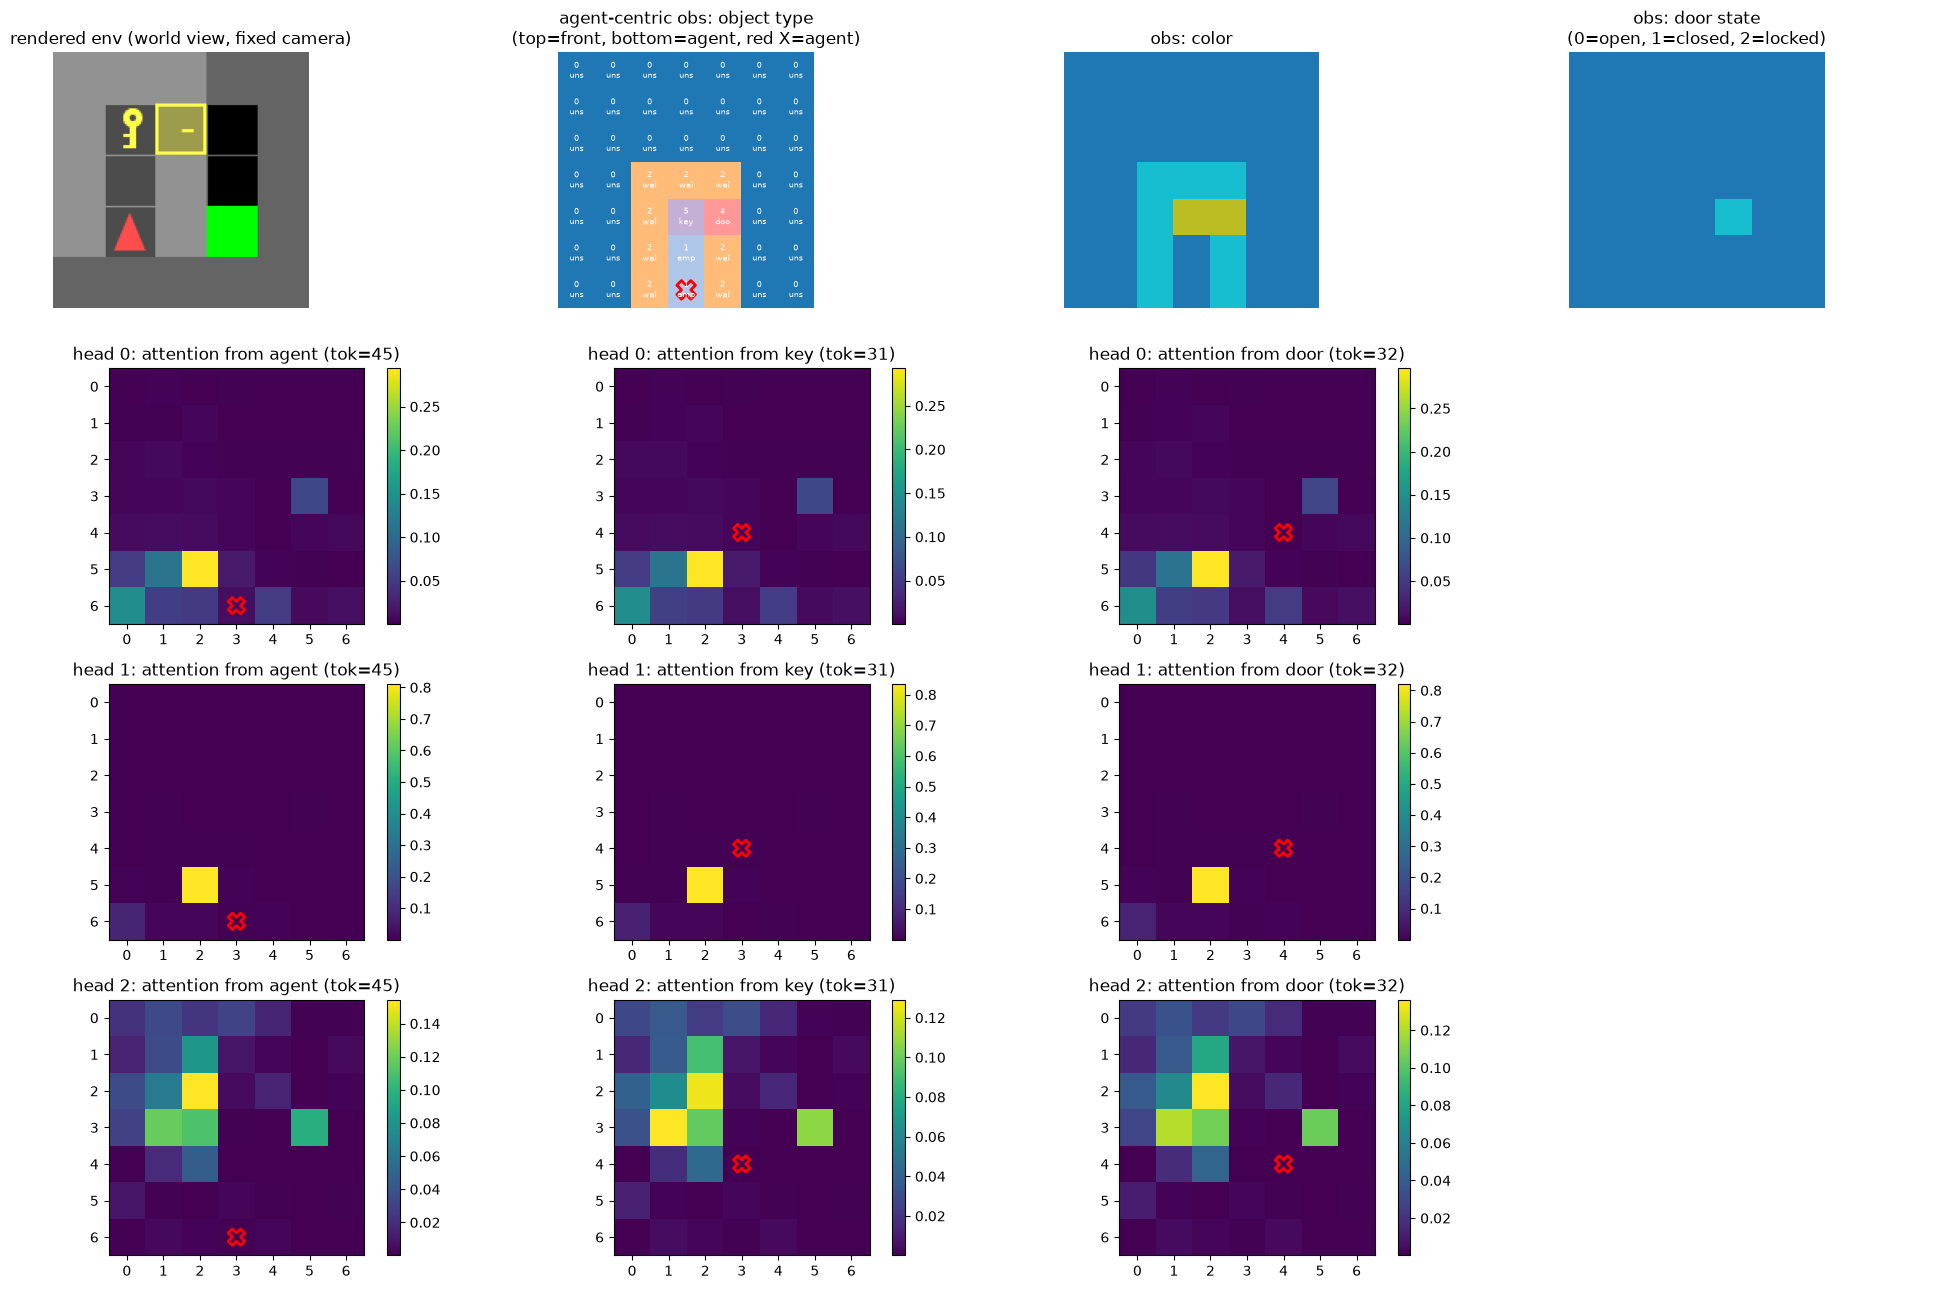

tokens picked: agent=45, key=31, door=32
agent_dir in world: 3  (0=east, 1=south, 2=west, 3=north)


In [19]:
from minigrid.core.constants import IDX_TO_OBJECT, OBJECT_TO_IDX
import matplotlib.pyplot as plt

# 1. 前向一次, 生成 att_map
state_ = env_vis.reset()
raw_obs = state_[0]  # (W, H, 3) MiniGrid 原生格式, W=横向, H=深度(0=前方, 6=代理)
state = torch.from_numpy(raw_obs).float().permute(2,1,0).unsqueeze(dim=0).to(device)
with torch.no_grad():
    _ = GWagent(state)

# 2. 从 (H, W) 视图里直接找关键物体的 token
#    state[0, 0] 形状 (H, W); token 顺序 = flatten(1,2) 行优先, index = row_H * 7 + col_W
#    自我中心视图: 代理隐式站在 row_H=6, col_W=3, 面朝 row_H=0
obj_HW = state[0, 0].cpu().numpy()  # (H, W), row=depth, col=lateral

def find_token_idx(obj_id):
    ys, xs = (obj_HW == obj_id).nonzero()  # ys=H-axis(row), xs=W-axis(col)
    if len(ys) == 0:
        return None
    return int(ys[0] * 7 + xs[0])

agent_row, agent_col = 6, 3
agent_token = agent_row * 7 + agent_col
key_token   = find_token_idx(OBJECT_TO_IDX['key'])
door_token  = find_token_idx(OBJECT_TO_IDX['door'])

focal = [('agent', agent_token), ('key', key_token), ('door', door_token)]

# 3. 顶部一排: 全景 + 三个观察通道
fig = plt.figure(figsize=(20, 4 + 3 * GWagent.n_heads))
gs = fig.add_gridspec(1 + GWagent.n_heads, 4, height_ratios=[1] + [1]*GWagent.n_heads)

ax_env = fig.add_subplot(gs[0, 0])
ax_env.imshow(env_vis.render())
ax_env.set_title('rendered env (world view, fixed camera)')
ax_env.axis('off')

# 观察面板: 不再 .T, 让 (H, W) 直接对应 imshow 的 (row, col)
# 结果: 顶部=前方, 底部=代理; 左=代理左侧, 右=代理右侧
ax_obj = fig.add_subplot(gs[0, 1])
ax_obj.imshow(obj_HW, cmap='tab20', vmin=0, vmax=11)
for r in range(7):
    for c in range(7):
        v = int(obj_HW[r, c])
        ax_obj.text(c, r, f"{v}\n{IDX_TO_OBJECT.get(v,'?')[:3]}",
                    ha='center', va='center', fontsize=6, color='white')
# 用红叉标出代理隐式位置
ax_obj.scatter([agent_col], [agent_row], marker='X', s=180,
               edgecolor='red', facecolor='none', linewidths=2)
ax_obj.set_title('agent-centric obs: object type\n(top=front, bottom=agent, red X=agent)')
ax_obj.axis('off')

col_HW = state[0, 1].cpu().numpy()
ax_col = fig.add_subplot(gs[0, 2])
ax_col.imshow(col_HW, cmap='tab10', vmin=0, vmax=5)
ax_col.set_title('obs: color')
ax_col.axis('off')

stt_HW = state[0, 2].cpu().numpy()
ax_stt = fig.add_subplot(gs[0, 3])
ax_stt.imshow(stt_HW, cmap='tab10', vmin=0, vmax=2)
ax_stt.set_title('obs: door state\n(0=open, 1=closed, 2=locked)')
ax_stt.axis('off')

# 4. n_heads × 3 的注意力网格: 每格是一个 head 里某个 focal token 作为 query 的 7x7 分布
for h in range(GWagent.n_heads):
    for j, (name, tok) in enumerate(focal):
        ax = fig.add_subplot(gs[h+1, j])
        if tok is None:
            ax.text(0.5, 0.5, f'{name} not in view',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'head {h}: {name} (missing)')
            ax.axis('off')
            continue
        att_row = GWagent.att_map[0, h, tok].cpu().numpy().reshape(7, 7)
        im = ax.imshow(att_row, cmap='viridis')
        # 标出 focal token 自身位置
        fy, fx = tok // 7, tok % 7
        ax.scatter([fx], [fy], marker='X', s=140,
                   edgecolor='red', facecolor='none', linewidths=2)
        ax.set_title(f'head {h}: attention from {name} (tok={tok})')
        ax.set_xticks(range(7))
        ax.set_yticks(range(7))
        plt.colorbar(im, ax=ax, fraction=0.046)

for h in range(GWagent.n_heads):
    fig.add_subplot(gs[h+1, 3]).axis('off')

plt.tight_layout()
plt.show()

print(f"tokens picked: agent={agent_token}, key={key_token}, door={door_token}")
print(f"agent_dir in world: {env_vis.unwrapped.agent_dir}  "
      f"(0=east, 1=south, 2=west, 3=north)")


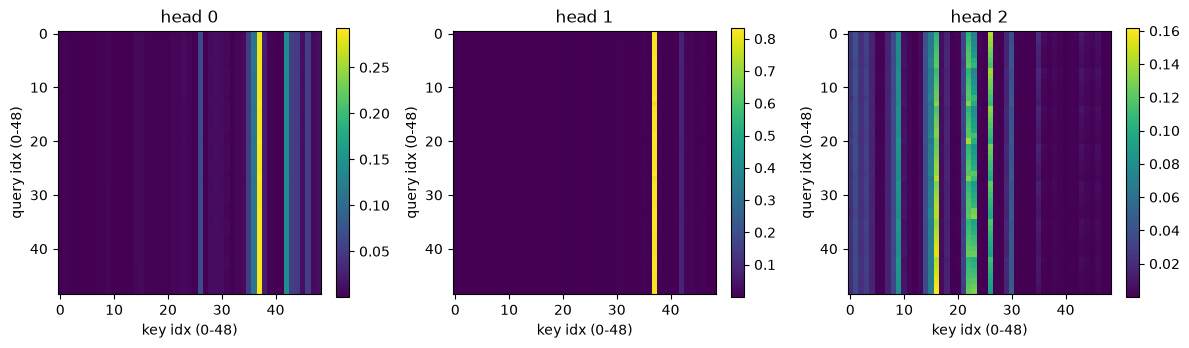

MultiHeadRelationalModule(
  (conv1): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(16, 20, kernel_size=(1, 1), stride=(1, 1))
  (k_proj): Linear(in_features=22, out_features=192, bias=True)
  (q_proj): Linear(in_features=22, out_features=192, bias=True)
  (v_proj): Linear(in_features=22, out_features=192, bias=True)
  (k_lin): Linear(in_features=64, out_features=49, bias=True)
  (q_lin): Linear(in_features=64, out_features=49, bias=True)
  (a_lin): Linear(in_features=49, out_features=49, bias=True)
  (k_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (q_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (v_norm): LayerNorm((3, 49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (linear1): Linear(in_features=192, out_features=64, bias=True)
  (norm1): LayerNorm((49, 64), eps=1e-05, elementwise_affine=False, bias=False)
  (linear2): Linear(in_features=64, out_features=5, bias=True)
)

In [20]:
# 可视化: 用一次前向后保存的 att_map 观察 3 个 head 的注意力分布
import matplotlib.pyplot as plt

GWagent.eval()
s = prepare_state(env.reset()[0])
with torch.no_grad():
    _ = GWagent(s)

# att_map: (B, n_heads, N, N) = (1, 3, 49, 49)
att = GWagent.att_map[0].cpu().numpy()  # (3, 49, 49)

fig, axes = plt.subplots(1, GWagent.n_heads, figsize=(4*GWagent.n_heads, 4))
for h in range(GWagent.n_heads):
    im = axes[h].imshow(att[h], cmap='viridis')
    axes[h].set_title(f'head {h}')
    axes[h].set_xlabel('key idx (0-48)')
    axes[h].set_ylabel('query idx (0-48)')
    plt.colorbar(im, ax=axes[h], fraction=0.046)
plt.tight_layout()
plt.show()
GWagent.train()


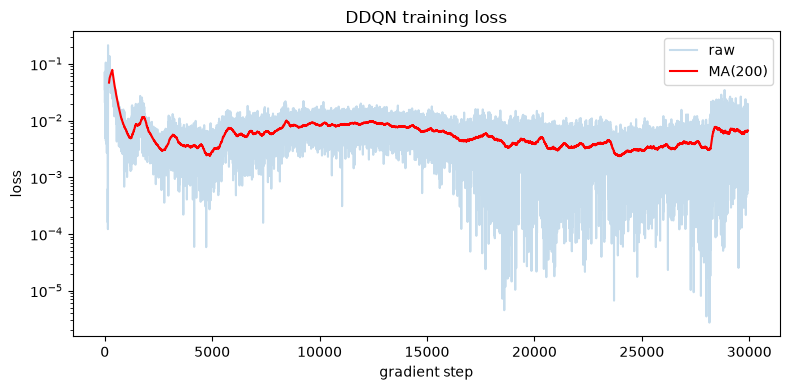

In [21]:

losses_arr = np.array(losses)
window = 200
if len(losses_arr) >= window:
    smooth = np.convolve(losses_arr, np.ones(window)/window, mode='valid')
else:
    smooth = losses_arr

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(losses_arr, alpha=0.25, label='raw')
ax.plot(np.arange(len(smooth)) + (len(losses_arr)-len(smooth)), smooth,
        color='red', label=f'MA({window})')
ax.set_xlabel('gradient step')
ax.set_ylabel('loss')
ax.set_yscale('log')
ax.legend()
ax.set_title('DDQN training loss')
plt.tight_layout()
plt.show()


In [22]:
losses[-1]

0.006411008536815643

In [23]:
losses

[0.021492406725883484,
 0.04014615714550018,
 0.07199429720640182,
 0.06053231656551361,
 0.042056407779455185,
 0.04111231118440628,
 0.05486607551574707,
 0.034356530755758286,
 0.04276089370250702,
 0.06993547081947327,
 0.07284978032112122,
 0.06077014282345772,
 0.04250708967447281,
 0.017253385856747627,
 0.01594139263033867,
 0.013498365879058838,
 0.0171189084649086,
 0.008288424462080002,
 0.016279958188533783,
 0.013605860061943531,
 0.010170282796025276,
 0.005286192987114191,
 0.012685578316450119,
 0.03345177322626114,
 0.031891219317913055,
 0.05507683381438255,
 0.041467610746622086,
 0.04698389023542404,
 0.04717497155070305,
 0.04929757118225098,
 0.044586844742298126,
 0.029658980667591095,
 0.013592864386737347,
 0.004857143387198448,
 0.02675909921526909,
 0.023120727390050888,
 0.02871290035545826,
 0.04554025083780289,
 0.05115305632352829,
 0.04158759117126465,
 0.04812365025281906,
 0.045252978801727295,
 0.028045888990163803,
 0.012782713398337364,
 0.009118168

In [24]:
# 1. 训练里 loss 是否真的更新过?
print(f"gradient steps: {len(losses)}, first={losses[0]:.4f}, last={losses[-1]:.4f}")

# 2. Replay 里有几条正奖励?
pos = sum(1 for e in replay if e[2] > 0)
print(f"positive-reward transitions in replay: {pos} / {len(replay)}")

# 3. 打印训练时的 return 需要在 loop 里加计数 — 见下面


gradient steps: 29936, first=0.0215, last=0.0064
positive-reward transitions in replay: 700 / 9000


In [25]:
import torch.nn.functional as F
import torch.nn.functional as F

tau = 1.0
q_tensor = torch.as_tensor(q, dtype=torch.float32)
probs = F.softmax(q_tensor / tau, dim=-1)


GWagent.eval()
env_test = ImgObsWrapper(gym.make('MiniGrid-DoorKey-5x5-v0'))
env_test.unwrapped.max_steps = 400

with torch.no_grad():
    s = prepare_state(env_test.reset()[0])
    for step in range(50):
        q = GWagent(s)
        a = int(torch.multinomial(probs, num_samples=1))
        s2, r, term, trunc, _ = env_test.step(action_map[a])
        print(f"step {step}: q={q.squeeze().cpu().numpy().round(2)}, action={a}, r={r}, term={term}")
        if term or trunc: break
        s = prepare_state(s2)


step 0: q=[0.26 0.25 0.26 0.26 0.26], action=3, r=0, term=False
step 1: q=[0.26 0.25 0.26 0.26 0.26], action=1, r=0, term=False
step 2: q=[0.26 0.25 0.26 0.26 0.26], action=2, r=0, term=False
step 3: q=[0.26 0.25 0.26 0.26 0.26], action=0, r=0, term=False
step 4: q=[0.26 0.25 0.26 0.26 0.26], action=0, r=0, term=False
step 5: q=[0.26 0.25 0.26 0.26 0.26], action=4, r=0, term=False
step 6: q=[0.26 0.25 0.26 0.26 0.26], action=2, r=0, term=False
step 7: q=[0.26 0.25 0.26 0.26 0.26], action=4, r=0, term=False
step 8: q=[0.26 0.25 0.26 0.26 0.26], action=0, r=0, term=False
step 9: q=[0.26 0.25 0.26 0.26 0.26], action=2, r=0, term=False
step 10: q=[0.26 0.25 0.26 0.26 0.26], action=0, r=0, term=False
step 11: q=[0.26 0.25 0.26 0.26 0.26], action=1, r=0, term=False
step 12: q=[0.26 0.25 0.26 0.26 0.26], action=0, r=0, term=False
step 13: q=[0.26 0.25 0.26 0.26 0.26], action=1, r=0, term=False
step 14: q=[0.26 0.25 0.26 0.26 0.26], action=0, r=0, term=False
step 15: q=[0.26 0.25 0.26 0.26 0.2